# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
194,-0.067268,-0.044642,-0.059019,0.032201,-0.051103,-0.049539,-0.010266,-0.039493,0.002004,0.023775,86.0
228,-0.052738,-0.044642,-0.012673,-0.060756,-0.000193,0.008081,0.011824,-0.002592,-0.027129,-0.050783,160.0
191,-0.005515,0.050680,-0.041774,-0.043542,-0.079998,-0.076156,-0.032356,-0.039493,0.010227,-0.009362,178.0
137,0.005383,-0.044642,0.049840,0.097615,-0.015328,-0.016345,-0.006584,-0.002592,0.017036,-0.013504,280.0
416,-0.027310,-0.044642,0.080019,0.098751,-0.002945,0.018101,-0.017629,0.003312,-0.029526,0.036201,257.0
431,0.070769,0.050680,-0.030996,0.021872,-0.037344,-0.047034,0.033914,-0.039493,-0.014960,-0.001078,66.0
136,-0.092695,-0.044642,-0.081653,-0.057313,-0.060735,-0.068014,0.048640,-0.076395,-0.066490,-0.021788,85.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
127,0.034443,0.050680,-0.001895,-0.012556,0.038334,0.013717,0.078093,-0.039493,0.004548,-0.096346,109.0
220,0.023546,0.050680,-0.039618,-0.005670,-0.048351,-0.033255,0.011824,-0.039493,-0.101640,-0.067351,78.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
data.isnull().sum()

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [6]:
data_simple = data.copy()

data_simple['bmi'] = data_simple['bmi'].fillna(data_simple['bmi'].mean())

data_simple['bmi'].isnull().sum()

np.int64(0)

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [7]:
from sklearn.impute import KNNImputer

data_knn = data.copy()

imputer = KNNImputer(n_neighbors=5)

data_knn[['bmi', 'bp']] = imputer.fit_transform(
    data_knn[['bmi', 'bp']]
)

print("Valores faltantes después de KNN:")
print(data_knn[['bmi', 'bp']].isnull().sum())

print("\nComparación de medias:")
print("Media original de bmi:", data['bmi'].mean())
print("Media después de imputación simple:", data_simple['bmi'].mean())
print("Media después de KNN:", data_knn['bmi'].mean())

Valores faltantes después de KNN:
bmi    0
bp     0
dtype: int64

Comparación de medias:
Media original de bmi: -0.00020486982495318998
Media después de imputación simple: -0.00020486982495319117
Media después de KNN: 0.00021273180711015857


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

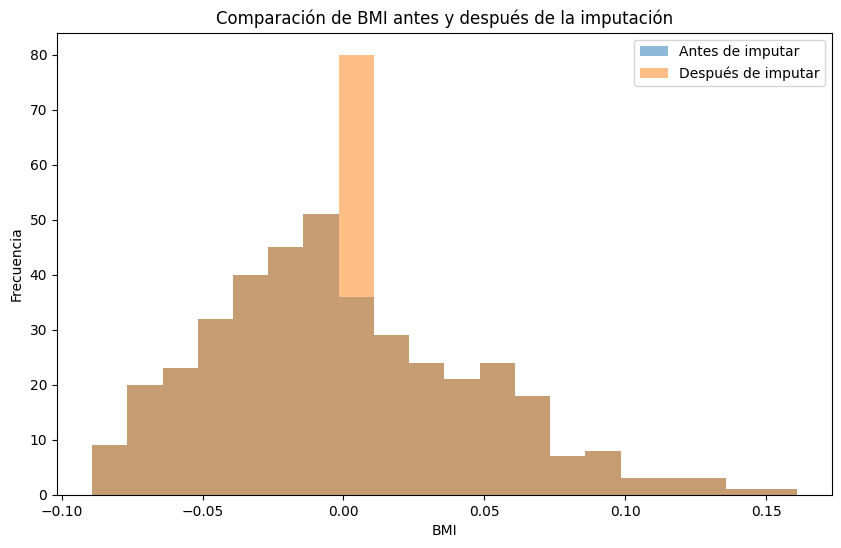

In [8]:
plt.figure(figsize=(10, 6))

plt.hist(data['bmi'].dropna(), bins=20, alpha=0.5, label='Antes de imputar')
plt.hist(data_simple['bmi'], bins=20, alpha=0.5, label='Después de imputar')

plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.title('Comparación de BMI antes y después de la imputación')
plt.legend()
plt.show()